# Фаза 1.6 — где ошибается бейзлайн

Шаг 1.5 дал одно число: **macro AP 0.3420 ± 0.0126** против пола 0.0349. Среднее по
138 дескрипторам скрывает почти всё интересное, а решать, что чинить в Фазе 2, надо
по деталям, а не по среднему.

Блокнот отвечает на четыре вопроса:

1. Правда ли, что модель проваливается именно на редких дескрипторах?
2. Какие дескрипторы получаются лучше всего, какие хуже всего, и есть ли в этом химическая логика?
3. На каких конкретно молекулах модель ошибается увереннее всего?
4. Не свёлся ли предсказатель `odorless` к «посмотри на молекулярную массу» (подозрение из журнала E-003)?

Модель — лучшая конфигурация из 1.5: логистическая регрессия с поблочным
масштабированием на наборе `morgan-bin-r3+desc`, стратифицированный сплит, сид 0.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sillage.metrics import evaluate
from sillage.models import MultilabelClassifier, logistic_regression
from sillage.research import feature_sets
from sillage.research.baseline import Dataset

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.3})

data = Dataset.load()
features = feature_sets.build("morgan-bin-r3+desc", data.molecules)
split = data.split("stratified", 0)

model = MultilabelClassifier(lambda: logistic_regression(features.names, seed=0))
model.fit(features.values[split.train], data.labels[split.train])
scores = model.predict_proba(features.values[split.test])

y_test = data.labels[split.test]
report = evaluate(y_test, scores, data.label_names)
print(report.summary())

macro AP  0.3511   (over 138 of 138 labels)
macro AUC 0.8699
micro AP  0.4416
micro AUC 0.9203


## 1. Качество против частоты дескриптора

Ожидание из EDA: чем реже дескриптор, тем хуже он предсказывается. Проверим — и сразу
рядом покажем **пол**: у случайного ранжирования AP равна доле положительных примеров.
Без этой линии график нечитаем, потому что у редких меток низкая AP может означать
и провал, и отличную работу.

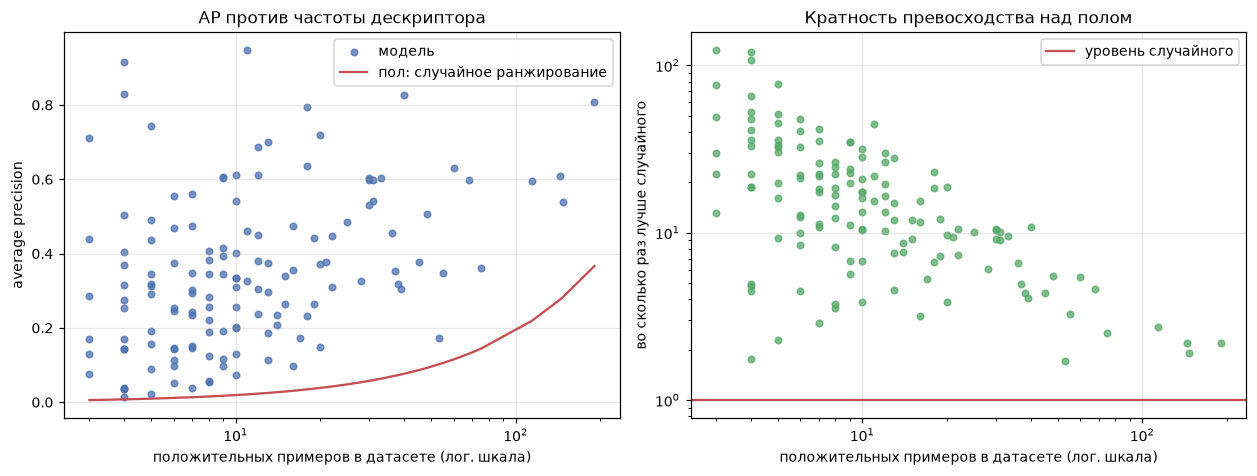

ранговая корреляция частоты и AP:        +0.380
ранговая корреляция частоты и кратности: -0.577


In [ ]:
table = report.per_label.copy()
test_prevalence = y_test.mean(axis=0)
table["test_positives"] = y_test.sum(axis=0)
table["baseline_ap"] = test_prevalence

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))

ax = axes[0]
ax.scatter(
    table["n_positive"],
    table["average_precision"],
    s=18,
    alpha=0.75,
    color="#4C72B0",
    label="модель",
)
order = table["n_positive"].argsort()
ax.plot(
    table["n_positive"].to_numpy()[order],
    table["baseline_ap"].to_numpy()[order],
    color="#C44E52",
    lw=1.5,
    label="пол: случайное ранжирование",
)
ax.set_xscale("log")
ax.set_xlabel("положительных примеров в датасете (лог. шкала)")
ax.set_ylabel("average precision")
ax.set_title("AP против частоты дескриптора")
ax.legend()

ax = axes[1]
ax.scatter(table["n_positive"], table["ap_lift"], s=18, alpha=0.75, color="#55A868")
ax.axhline(1.0, color="#C44E52", lw=1.5, label="уровень случайного")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("положительных примеров в датасете (лог. шкала)")
ax.set_ylabel("во сколько раз лучше случайного")
ax.set_title("Кратность превосходства над полом")
ax.legend()
plt.tight_layout()
plt.show()

rho = table["n_positive"].corr(table["average_precision"], method="spearman")
rho_lift = table["n_positive"].corr(table["ap_lift"], method="spearman")
print(f"ранговая корреляция частоты и AP:        {rho:+.3f}")
print(f"ранговая корреляция частоты и кратности: {rho_lift:+.3f}")

Два графика говорят **противоположные** вещи, и в этом весь смысл раздела.

Слева видно ожидаемое: у редких дескрипторов AP низкая. Но красная линия показывает,
что у них и пол низкий — им просто негде набрать высокую AP.

Справа — та же модель, но по отношению к полу. Картина переворачивается: **на редких
дескрипторах модель превосходит случайное угадывание в десятки раз**, а на частых —
всего в два-три раза. Абсолютная AP падает с редкостью, относительная — растёт.

Вывод для Фазы 2: утверждение «модель плохо работает на редких классах» в такой форме
**неверно**. Она работает на них лучше, чем на частых, — просто задача там заведомо
труднее. Чинить надо не «редкие классы» вообще.

## 2. Лучшие и худшие дескрипторы

Смотрим не на AP, а на кратность превосходства над полом — она сравнима между
дескрипторами с разной частотой.

In [ ]:
show = ["n_positive", "test_positives", "baseline_ap", "average_precision", "ap_lift", "roc_auc"]
best = table.nlargest(12, "ap_lift")[show]
worst = table.nsmallest(12, "ap_lift")[show]

print("ЛУЧШЕ ВСЕГО (по кратности над полом)")
print(best.round(3).to_string())
print()
print("ХУЖЕ ВСЕГО")
print(worst.round(3).to_string())

ЛУЧШЕ ВСЕГО (по кратности над полом)
          n_positive  test_positives  baseline_ap  average_precision  ap_lift  roc_auc
label                                                                                 
malty              3               3        0.006              0.712  123.672    0.988
popcorn            4               4        0.008              0.917  119.396    0.999
clove              4               4        0.008              0.830  108.154    0.998
ketonic            5               5        0.010              0.743   77.455    0.997
gassy              3               3        0.006              0.440   76.374    0.983
celery             4               4        0.008              0.504   65.684    0.605
sweaty             4               4        0.008              0.404   52.673    0.912
hazelnut           5               5        0.010              0.490   51.104    0.950
bergamot           3               3        0.006              0.285   49.447    0.907
leathe

## 3. Двадцать худших предсказаний

Две разные ошибки, и их полезно разделять.

**Ложная тревога** — модель уверенно ставит высокий балл там, где метки нет.
**Промах** — метка есть, а балл низкий.

Берём по десять самых вопиющих случаев каждого рода.

In [ ]:
smiles_test = [data.molecules[i] for i in split.test]
from rdkit import Chem

texts = [Chem.MolToSmiles(m) for m in smiles_test]
names = np.array(data.label_names)

rows_fa, rows_miss = [], []
for mol_index in range(len(y_test)):
    for label_index in range(len(names)):
        record = {
            "smiles": texts[mol_index],
            "дескриптор": names[label_index],
            "балл": scores[mol_index, label_index],
            "мол.индекс": mol_index,
        }
        if y_test[mol_index, label_index] == 0:
            rows_fa.append(record)
        else:
            rows_miss.append(record)

false_alarms = pd.DataFrame(rows_fa).nlargest(10, "балл")
misses = pd.DataFrame(rows_miss).nsmallest(10, "балл")

print("ЛОЖНЫЕ ТРЕВОГИ: модель уверена, метки нет")
print(false_alarms[["smiles", "дескриптор", "балл"]].round(3).to_string(index=False))
print()
print("ПРОМАХИ: метка есть, модель не увидела")
print(misses[["smiles", "дескриптор", "балл"]].round(3).to_string(index=False))

ЛОЖНЫЕ ТРЕВОГИ: модель уверена, метки нет
                                                                                           smiles  дескриптор  балл
                                                                       O=C([O-])[O-].[Mg+2].[OH-] camphoreous 1.000
                                                                       O=C([O-])[O-].[Mg+2].[OH-]    ethereal 1.000
                                                                       O=C([O-])[O-].[Mg+2].[OH-]   fermented 1.000
                                                                       O=C([O-])[O-].[Mg+2].[OH-]       fishy 1.000
                                                                       O=C([O-])[O-].[Mg+2].[OH-]       musty 1.000
                                                                       O=C([O-])[O-].[Mg+2].[OH-]        oily 1.000
                                                                       O=C([O-])[O-].[Mg+2].[OH-]      sweaty 1.000
CC(NC1C(C)(C)SC1(C)C)C(=O)NC(=

Ложные тревоги


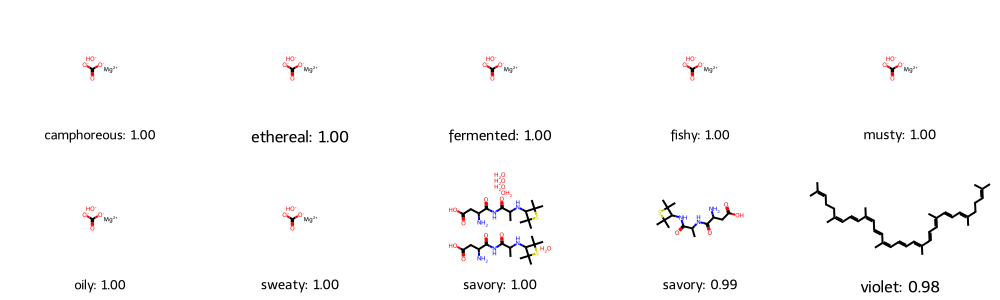

In [ ]:
from rdkit.Chem import Draw


def draw_cases(frame, title):
    mols = [smiles_test[i] for i in frame["мол.индекс"]]
    legends = [f"{r['дескриптор']}: {r['балл']:.2f}" for _, r in frame.iterrows()]
    print(title)
    return Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(200, 150), legends=legends)


draw_cases(false_alarms, "Ложные тревоги")

Промахи


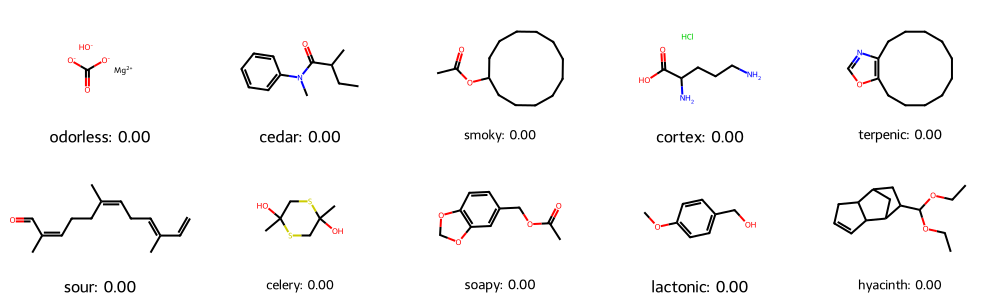

In [ ]:
draw_cases(misses, "Промахи")

### Главная находка: уверенная чушь на входах вне распределения

Список ложных тревог возглавляет одна и та же молекула — `O=C([O-])[O-].[Mg+2].[OH-]`,
основной карбонат магния. Неорганическая соль. Модель ставит ей балл **1.000** сразу
за семь дескрипторов: `camphoreous`, `ethereal`, `fermented`, `fishy`, `musty`, `oily`,
`sweaty`.

А в списке промахов та же молекула стоит с баллом **0.0** за `odorless` — свою
настоящую и единственную метку.

Разберёмся, почему.

In [ ]:
mg_smiles = "O=C([O-])[O-].[Mg+2].[OH-]"
mg_index = next(i for i, t in enumerate(texts) if t == mg_smiles)
bits = [i for i, n in enumerate(features.names) if n.startswith("morgan_")]
row = features.values[split.test[mg_index]]
average_bits = features.values[:, bits].sum(axis=1).mean()

print("основной карбонат магния")
print(f"  морган-битов зажжено:                  {int(row[bits].sum())} из {len(bits)}")
print(f"  в среднем по датасету:                 {average_bits:.0f}")
print()
odorless_column = list(data.label_names).index("odorless")
print(f"  максимальный балл по 138 дескрипторам:  {scores[mg_index].max():.3f}")
print(f"  балл за настоящую метку odorless:      {scores[mg_index, odorless_column]:.3f}")
print(f"  дескрипторов с баллом выше 0.9:        {int((scores[mg_index] > 0.9).sum())}")
print(f"  в среднем по тестовой части:           {(scores > 0.9).sum(axis=1).mean():.1f}")

основной карбонат магния
  морган-битов зажжено:                  8 из 2048
  в среднем по датасету:                 29

  максимальный балл по 138 дескрипторам:  1.000
  балл за настоящую метку odorless:      0.000
  дескрипторов с баллом выше 0.9:        7
  в среднем по тестовой части:           0.2


Причина в том, что молекула **непохожа ни на что в обучении**. Она ионная, крошечная,
почти не даёт морган-фрагментов. Признаковый вектор оказывается вне области, где модель
хоть что-то видела, — и линейная модель бодро экстраполирует в пустоту, выдавая
единицы.

Это самое ценное наблюдение всего шага, и вот почему: **модель не имеет способа
сказать «я не знаю»**. Балл 1.000 у неё означает и «уверенно пахнет рыбой», и «понятия
не имею, что это». Различить эти два случая по выходу невозможно.

Для продукта это прямая угроза: пользователь введёт SMILES чего-нибудь необычного и
получит уверенный, красивый и полностью выдуманный профиль. Именно поэтому в плане
Фазы 2 калибровка и оценка неопределённости стоят выше, чем сама архитектура GNN.

Ложные тревоги стоит читать не как ошибки модели, а как **вопросы к разметке**.
Если модель уверенно ставит `fruity` молекуле, которой эксперт этого не приписал,
возможны два объяснения: модель ошиблась — или эксперт не указал очевидное, потому
что перечислял не всё. Второе в таких датасетах встречается постоянно: разметка
неполна, а не неверна.

Различить их без нового эксперимента нельзя, и это ограничение надо назвать вслух,
а не списать всё на модель.

## 4. Проверка подозрения из E-003: `odorless` и молекулярная масса

В разведке обнаружилось, что все самые тяжёлые молекулы датасета (циклодекстрины
до 1347 Da) помечены `odorless`. Физика очевидна: не испаряется — не пахнет.

Но отсюда следует неприятная возможность: модель могла выучить не «эта молекула
не пахнет», а просто «эта молекула большая». Ответ был бы правильным по неправильной
причине и развалился бы на молекулах другого типа.

Проверка прямая: обучим предсказатель `odorless` **на одном-единственном признаке** —
молекулярной массе — и сравним с полной моделью.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from sillage.features import rdkit_descriptors
from sillage.metrics import average_precision

descriptors = rdkit_descriptors(data.molecules)
weight = descriptors.values[:, descriptors.names.index("MolWt")].reshape(-1, 1)
odorless = list(data.label_names).index("odorless")

only_weight = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
only_weight.fit(weight[split.train], data.labels[split.train, odorless])
weight_scores = only_weight.predict_proba(weight[split.test])[:, 1]

y_odorless = y_test[:, odorless]
ap_full = table.loc["odorless", "average_precision"]
ap_weight = average_precision(y_odorless, weight_scores)
ap_floor = y_odorless.mean()

print(f"положительных примеров odorless в тесте: {int(y_odorless.sum())}")
print()
print(f"пол (случайное ранжирование):      {ap_floor:.4f}")
print(
    f"только молекулярная масса:         {ap_weight:.4f}   (x{ap_weight / ap_floor:.1f} над полом)"
)
print(f"полная модель, 2264 признака:      {ap_full:.4f}   (x{ap_full / ap_floor:.1f} над полом)")
print()
print(f"доля результата, объяснимая одной массой: {ap_weight / ap_full * 100:.0f}%")

положительных примеров odorless в тесте: 20

пол (случайное ранжирование):      0.0384
только молекулярная масса:         0.3282   (x8.5 над полом)
полная модель, 2264 признака:      0.7205   (x18.8 над полом)

доля результата, объяснимая одной массой: 46%


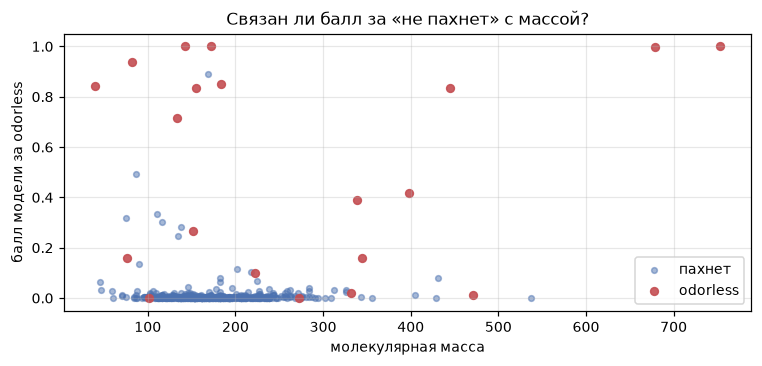

корреляция массы и балла модели: +0.208


In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.4))
mass_test = weight[split.test].ravel()
ax.scatter(
    mass_test[y_odorless == 0],
    scores[y_odorless == 0, odorless],
    s=14,
    alpha=0.5,
    color="#4C72B0",
    label="пахнет",
)
ax.scatter(
    mass_test[y_odorless == 1],
    scores[y_odorless == 1, odorless],
    s=26,
    alpha=0.9,
    color="#C44E52",
    label="odorless",
)
ax.set_xlabel("молекулярная масса")
ax.set_ylabel("балл модели за odorless")
ax.set_title("Связан ли балл за «не пахнет» с массой?")
ax.legend()
plt.tight_layout()
plt.show()

corr = np.corrcoef(mass_test, scores[:, odorless])[0, 1]
print(f"корреляция массы и балла модели: {corr:+.3f}")

## Выводы

**1. «Модель плохо работает на редких дескрипторах» — неверно.** Ранговая корреляция
частоты с абсолютной AP положительна (+0.38), но с кратностью над полом —
**отрицательна (−0.58)**. На редких метках модель превосходит случайное угадывание в
десятки раз, на частых — в два-три. Абсолютные числа там ниже просто потому, что и пол
ниже. Специальная работа с дисбалансом в Фазе 2 не приоритет.

**2. Модель сильна на конкретных запахах и слаба на расплывчатых.** Лидеры по
кратности — `malty` (×124), `popcorn` (×119), `clove` (×108), `ketonic` (×77). За
каждым стоит узкое химическое семейство: гвоздика — это эвгенол, попкорн —
пиразины и пирролины. Одна структура, один запах, модель ловит его почти идеально.

Аутсайдеры — `fresh` (×1.7), `weedy` (×1.8), `sweet` (×1.9), `green` (×2.2). Это
частые зонтичные термины, которые эксперты вешают на структурно несвязанные молекулы.
Здесь ограничение не в модели, а в самом дескрипторе: «свежий» не соответствует
никакому структурному признаку.

**3. Модель уверенно врёт на входах вне распределения и не может об этом сообщить.**
Карбонат магния получает 1.000 за семь дескрипторов и 0.0 за свою настоящую метку.
Это главный аргумент в пользу того, что калибровка и оценка неопределённости в Фазе 2
важнее выбора архитектуры.

**4. Подозрение из E-003 подтвердилось наполовину.** Предсказатель `odorless`,
построенный на одной молекулярной массе, даёт AP 0.328 — это 46% от результата полной
модели (0.721) и в 8.5 раза выше пола. Масса действительно работает как ярлык. Но
полная модель вдвое лучше, а корреляция массы с её баллом всего +0.21, так что к одной
массе предсказание не сводится.

## Что из этого следует для Фазы 2

| Приоритет | Что делать | Почему |
| --- | --- | --- |
| Высокий | Калибровка вероятностей, детекция входов вне распределения | Модель не умеет говорить «не знаю»; для публичного сервиса это опаснее низкой метрики |
| Высокий | Считать метрики отдельно по «конкретным» и «зонтичным» дескрипторам | Среднее по 138 смешивает две принципиально разные задачи |
| Средний | GNN как другое представление молекулы | Плато 0.34 упирается в представление ([E-006](../docs/journal/experiments.md)) |
| Низкий | Работа с дисбалансом классов | Относительно пола модель на редких метках уже сильна |